# Comparison: Monte Carlo Methods vs Theoretical Airy Pattern

This notebook compares Monte Carlo approaches for simulating photon propagation:
1. **Aperture Sampling vs Theoretical Airy**: Validate aperture sampling method
2. **Aperture Sampling vs Angular Spectrum**: Compare two MC approaches

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1
from scipy.interpolate import interp1d

# Import and reload modules to pick up changes
from monte_carlo.core import ApertureSimulator
from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo import metrics
import importlib
import monte_carlo.core
import monte_carlo.angular_spectrum
import monte_carlo.metrics
importlib.reload(monte_carlo.core)
importlib.reload(monte_carlo.angular_spectrum)
importlib.reload(monte_carlo.metrics)
from monte_carlo.core import ApertureSimulator
from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo import metrics

# Set seaborn style
sns.set_theme(style="whitegrid", font_scale=2.0)

# Create output directory
import os
output_dir = '../data/compare_methods'
os.makedirs(output_dir, exist_ok=True)

# Helper function to compute FWHM
def compute_fwhm(r_centers, intensity):
    """
    Compute Full Width at Half Maximum (FWHM) from radial intensity profile.
    
    Parameters
    ----------
    r_centers : np.ndarray
        Radial distance values
    intensity : np.ndarray
        Normalized intensity values (peak = 1.0)
    
    Returns
    -------
    float
        FWHM value (diameter at half maximum)
    """
    # Find where intensity crosses 0.5
    half_max = 0.5
    
    # Find indices where intensity is above half max
    above_half = intensity >= half_max
    
    if not np.any(above_half):
        return np.nan
    
    # Find the last point above half max (going outward from center)
    try:
        # Find approximate crossing point
        crossing_idx = np.where(np.diff(above_half.astype(int)) < 0)[0]
        
        if len(crossing_idx) == 0:
            return np.nan
        
        # Use first crossing (going outward from center)
        idx = crossing_idx[0]
        
        # Refine with linear interpolation
        r_range = r_centers[idx:idx+2]
        i_range = intensity[idx:idx+2] - half_max
        
        # Linear interpolation to find zero crossing
        r_half_max = r_range[0] - i_range[0] * (r_range[1] - r_range[0]) / (i_range[1] - i_range[0])
        
        fwhm = 2 * r_half_max
        return fwhm
    except:
        return np.nan

## Setup Parameters

In [2]:
# Simulation parameters
n_photons = 1000000  # Increased for better statistics
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
numerical_aperture = 0.1
n_medium = 1.0
random_seed = 42
fft_size = 16384  # Very high resolution for angular spectrum (was 2048)
n_trials = 1  # Single trial for comparison

airy_radius = 1.22 * wavelength / numerical_aperture

print(f"Running simulations with {n_photons} photons per trial...")
print(f"Number of trials: {n_trials}")
print(f"Wavelength: {wavelength} μm ({wavelength*1000:.1f} nm)")
print(f"NA: {numerical_aperture}")
print(f"Focal length: {focal_length} mm")
print(f"FFT size: {fft_size}")
print(f"First Airy zero: {airy_radius:.4f} μm")

Running simulations with 1000000 photons per trial...
Number of trials: 1
Wavelength: 0.6328 μm (632.8 nm)
NA: 0.1
Focal length: 10.0 mm
FFT size: 16384
First Airy zero: 7.7202 μm


## Run Simulations

In [3]:
# Run multiple trials and collect results
print("Running multiple trials...")

# Storage for all trials
all_x_ap = []
all_y_ap = []
all_x_ang = []
all_y_ang = []
all_kx = []
all_ky = []
all_kz = []

# Create trial subdirectory
trial_dir = f'{output_dir}/trials'
os.makedirs(trial_dir, exist_ok=True)

for trial in range(n_trials):
    print(f"\nTrial {trial+1}/{n_trials}...")
    
    # Create simulators with different seeds
    aperture_sim = ApertureSimulator(
        n_photons=n_photons,
        wavelength=wavelength,
        focal_length=focal_length,
        numerical_aperture=numerical_aperture,
        n_medium=n_medium,
        random_seed=random_seed + trial
    )
    
    angular_sim = AngularSpectrumSimulator(
        n_photons=n_photons,
        wavelength=wavelength,
        focal_length=focal_length,
        numerical_aperture=numerical_aperture,
        n_medium=n_medium,
        random_seed=random_seed + n_trials + trial,
        fft_size=fft_size
    )
    
    # Run simulations
    aperture_results = aperture_sim.propagate()
    angular_results = angular_sim.propagate()
    
    # Extract positions
    x_ap, y_ap, z_ap = aperture_results['focal_positions']
    x_ang, y_ang, z_ang = angular_results['focal_positions']
    kx, ky, kz = angular_results['k_vectors']
    
    # Store for averaging
    all_x_ap.extend(x_ap)
    all_y_ap.extend(y_ap)
    all_x_ang.extend(x_ang)
    all_y_ang.extend(y_ang)
    all_kx.extend(kx)
    all_ky.extend(ky)
    all_kz.extend(kz)
    
    # Save quick comparison plot for this trial
    r_ap_trial = np.sqrt(x_ap**2 + y_ap**2)
    r_ang_trial = np.sqrt(x_ang**2 + y_ang**2)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.hist(r_ap_trial, bins=100, alpha=0.5, label='Aperture Sampling', density=True, color='blue')
    ax.hist(r_ang_trial, bins=100, alpha=0.5, label='Angular Spectrum', density=True, color='red')
    ax.set_xlabel('Radial Distance (μm)', fontsize=14)
    ax.set_ylabel('Probability Density', fontsize=14)
    ax.set_title(f'Trial {trial+1}: Radial Distribution Comparison', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{trial_dir}/trial_{trial+1:02d}_radial_hist.png', dpi=150, bbox_inches='tight')
    plt.close()

# Convert to arrays
x_ap = np.array(all_x_ap)
y_ap = np.array(all_y_ap)
x_ang = np.array(all_x_ang)
y_ang = np.array(all_y_ang)
kx = np.array(all_kx)
ky = np.array(all_ky)
kz = np.array(all_kz)

k = 2 * np.pi * n_medium / wavelength

print(f"\nAll {n_trials} trials complete!")
print(f"Total photons collected per method: {len(x_ap):,}")
print(f"\nVerifying k-vector physics (Angular Spectrum):")
print(f"  k = 2πn/λ = {k:.4f}")
print(f"  k_max (from NA) = {angular_sim.k_max:.4f}")
print(f"  max(√(kx²+ky²)) = {np.sqrt(kx**2 + ky**2).max():.4f}")
print(f"  Checking k² = kx² + ky² + kz²:")
k_magnitude = np.sqrt(kx**2 + ky**2 + kz**2)
print(f"    Expected: {k:.6f}")
print(f"    Got (mean): {k_magnitude.mean():.6f}")
print(f"    Relative error: {np.abs(k_magnitude - k).max() / k * 100:.6f}%")
print(f"\nSaved {n_trials} trial comparison plots to {trial_dir}/")

Running multiple trials...

Trial 1/1...



All 1 trials complete!
Total photons collected per method: 1,000,000

Verifying k-vector physics (Angular Spectrum):
  k = 2πn/λ = 9.9292
  k_max (from NA) = 0.9929
  max(√(kx²+ky²)) = 9.9277
  Checking k² = kx² + ky² + kz²:
    Expected: 9.929180
    Got (mean): 9.929180
    Relative error: 0.000000%

Saved 1 trial comparison plots to ../data/compare_methods/trials/


## Angular Spectrum Visualization

Visualize the k-space distribution that we're sampling from for the angular spectrum method.

/var/folders/t1/s8yj2ln96qv9sr5bwcjsq4mm0000gn/T/ipykernel_6967/3500233417.py:68: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.tight_layout()
/var/folders/t1/s8yj2ln96qv9sr5bwcjsq4mm0000gn/T/ipykernel_6967/3500233417.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.savefig(f'{output_dir}/angular_spectrum_kspace.png', dpi=150, bbox_inches='tight')


/opt/homebrew/Caskroom/miniforge/base/envs/misc/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


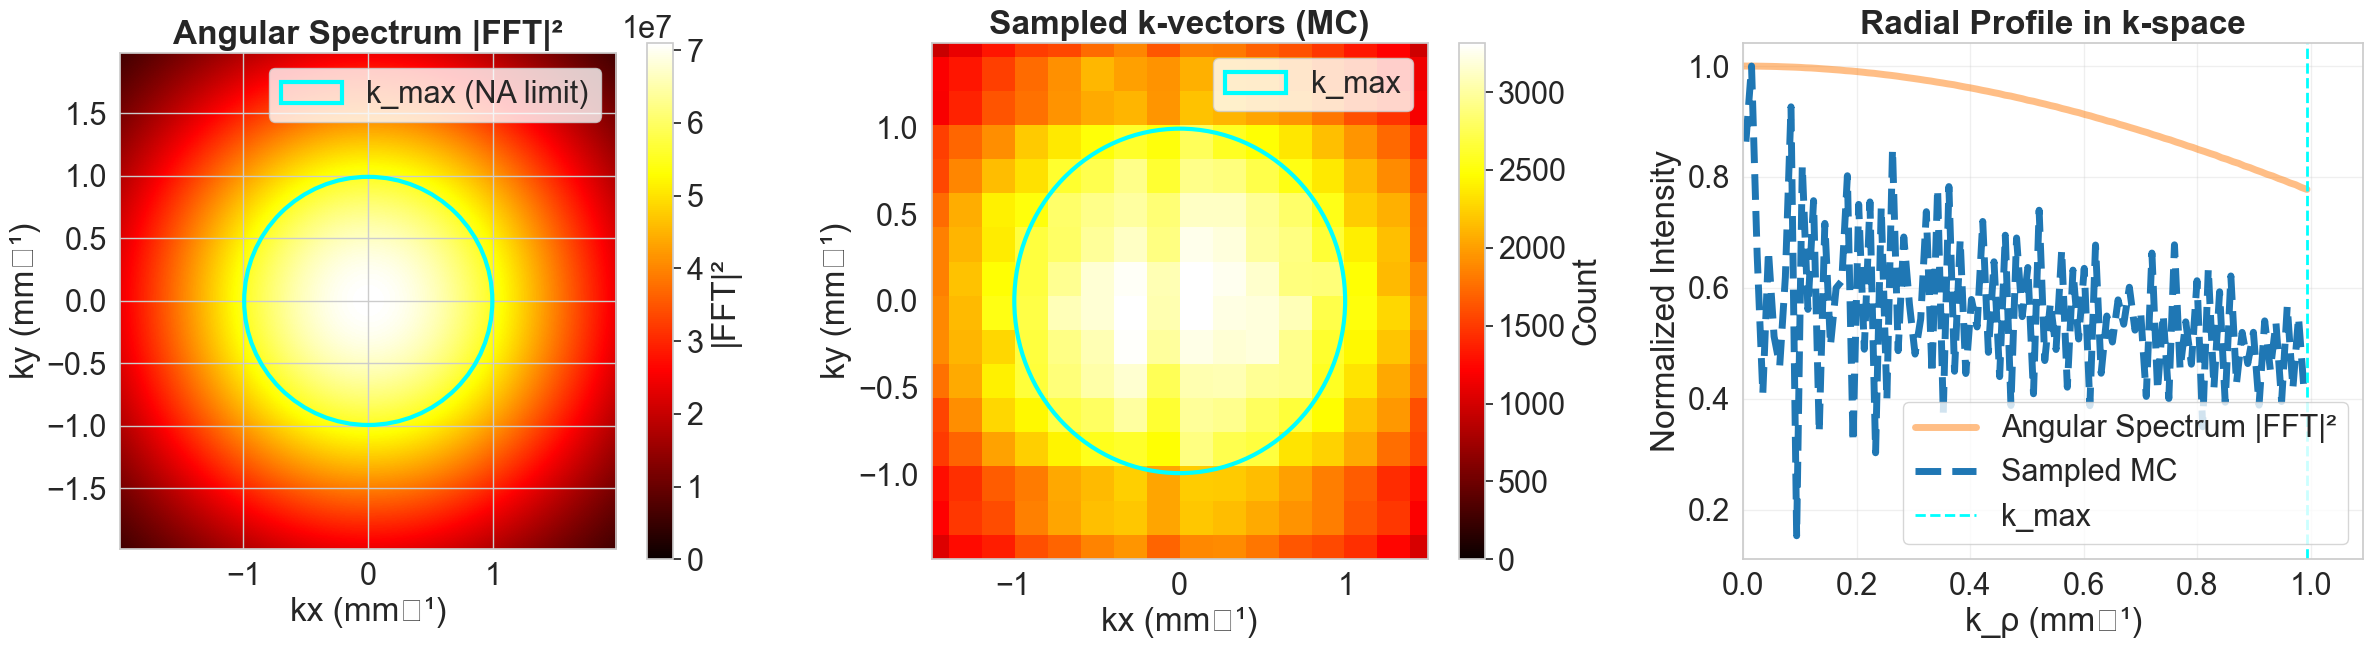


Angular Spectrum Info:
  FFT grid size: 16384 x 16384
  Valid k-vectors within NA: 785349
  k_max = 0.9929 mm⁻¹
  Sampled k_ρ range: [0.0000, 9.9277] mm⁻¹
  Mean k_ρ: 2.0201 mm⁻¹ (203.4% of k_max)


In [4]:
# Visualize the angular spectrum in k-space
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot 1: 2D Angular Spectrum from FFT
ax = axes[0]
extent = [angular_sim.kx_grid.min(), angular_sim.kx_grid.max(), 
          angular_sim.ky_grid.min(), angular_sim.ky_grid.max()]
im = ax.imshow(angular_sim.angular_spectrum_2d, origin='lower', extent=extent, cmap='hot')
plt.colorbar(im, ax=ax, label='|FFT|²')
ax.set_xlabel('kx (mm⁻¹)')
ax.set_ylabel('ky (mm⁻¹)')
ax.set_title('Angular Spectrum |FFT|²', fontweight='bold')
circle = plt.Circle((0, 0), angular_sim.k_max, fill=False, color='cyan', linewidth=3, label='k_max (NA limit)')
ax.add_patch(circle)
ax.legend()
ax.set_xlim(-2*angular_sim.k_max, 2*angular_sim.k_max)
ax.set_ylim(-2*angular_sim.k_max, 2*angular_sim.k_max)

# Plot 2: 2D histogram of sampled (kx, ky)
ax = axes[1]
h = ax.hist2d(kx, ky, bins=100, cmap='hot')
plt.colorbar(h[3], ax=ax, label='Count')
ax.set_xlabel('kx (mm⁻¹)')
ax.set_ylabel('ky (mm⁻¹)')
ax.set_title('Sampled k-vectors (MC)', fontweight='bold')
circle = plt.Circle((0, 0), angular_sim.k_max, fill=False, color='cyan', linewidth=3, label='k_max')
ax.add_patch(circle)
ax.legend()
ax.set_xlim(-1.5*angular_sim.k_max, 1.5*angular_sim.k_max)
ax.set_ylim(-1.5*angular_sim.k_max, 1.5*angular_sim.k_max)

# Plot 3: Radial profile comparison
ax = axes[2]
k_rho_grid = np.sqrt(angular_sim.kx_grid**2 + angular_sim.ky_grid**2)
k_rho_vals = np.linspace(0, angular_sim.k_max, 100)
angular_spectrum_radial = []

for k_r in k_rho_vals:
    mask = (k_rho_grid >= k_r - angular_sim.k_max/50) & (k_rho_grid < k_r + angular_sim.k_max/50)
    if np.any(mask):
        angular_spectrum_radial.append(np.mean(angular_sim.angular_spectrum_2d[mask]))
    else:
        angular_spectrum_radial.append(0)

# Normalize for comparison
angular_spectrum_radial = np.array(angular_spectrum_radial)
angular_spectrum_radial = angular_spectrum_radial / np.max(angular_spectrum_radial)

# Sampled radial distribution
k_rho_sampled = np.sqrt(kx**2 + ky**2)
hist_k, bin_edges = np.histogram(k_rho_sampled, bins=100, range=(0, angular_sim.k_max))
k_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# Normalize by annulus area
bin_areas_k = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
hist_k_normalized = hist_k / bin_areas_k
hist_k_normalized = hist_k_normalized / np.max(hist_k_normalized)

ax.plot(k_rho_vals, angular_spectrum_radial, linewidth=5, label='Angular Spectrum |FFT|²', color='tab:orange', alpha=0.5)
ax.plot(k_centers, hist_k_normalized, linewidth=5, label='Sampled MC', linestyle='--', color='tab:blue')
ax.set_xlabel('k_ρ (mm⁻¹)')
ax.set_ylabel('Normalized Intensity')
ax.set_title('Radial Profile in k-space', fontweight='bold')
ax.axvline(angular_sim.k_max, color='cyan', linestyle='--', linewidth=2, label='k_max')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, angular_sim.k_max * 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/angular_spectrum_kspace.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAngular Spectrum Info:")
print(f"  FFT grid size: {angular_sim.fft_size} x {angular_sim.fft_size}")
print(f"  Valid k-vectors within NA: {len(angular_sim.kx_valid)}")
print(f"  k_max = {angular_sim.k_max:.4f} mm⁻¹")
print(f"  Sampled k_ρ range: [{k_rho_sampled.min():.4f}, {k_rho_sampled.max():.4f}] mm⁻¹")
print(f"  Mean k_ρ: {k_rho_sampled.mean():.4f} mm⁻¹ ({k_rho_sampled.mean()/angular_sim.k_max*100:.1f}% of k_max)")


## Part 1: Aperture Sampling vs Theoretical Airy Pattern

First, validate that the aperture sampling method produces the expected Airy diffraction pattern.

### 2D Pattern Comparison

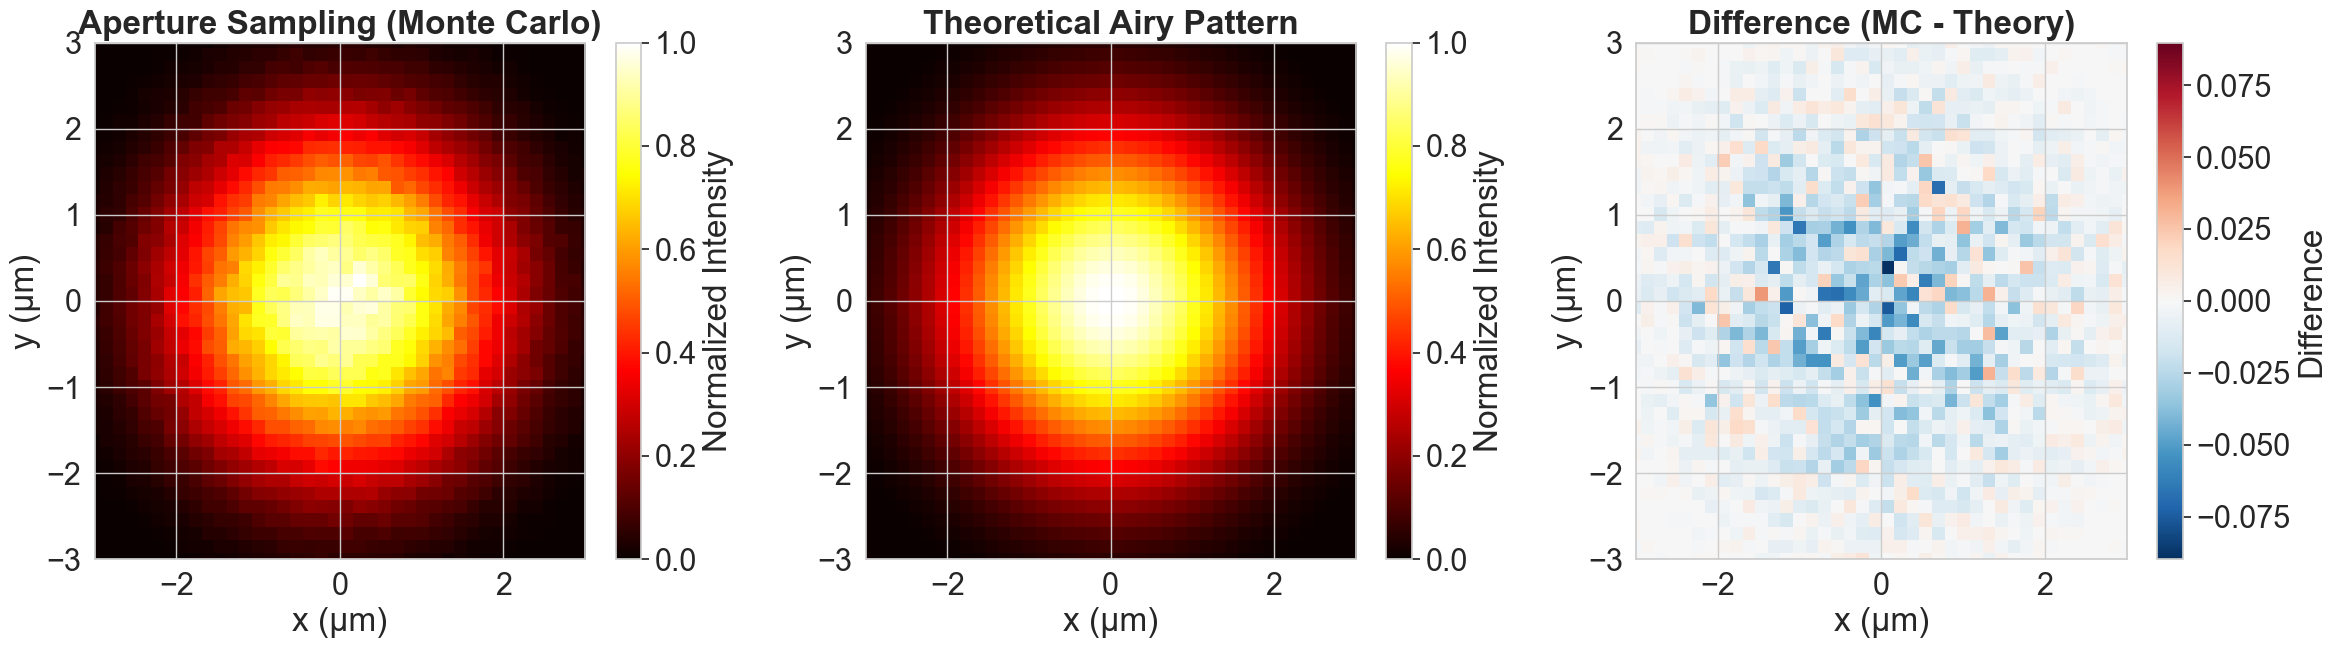

Max absolute difference: 0.089791


In [5]:
# Higher resolution for smoother images
bins_2d = 200
extent_factor = 2
plot_range = extent_factor * airy_radius

# Create 2D histogram for aperture method
hist_ap, xedges, yedges = np.histogram2d(
    x_ap, y_ap, bins=bins_2d, 
    range=[[-plot_range, plot_range], [-plot_range, plot_range]]
)

# Create theoretical Airy pattern on same grid
x_grid = (xedges[:-1] + xedges[1:]) / 2
y_grid = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
R = np.sqrt(X**2 + Y**2)

k_theory = 2 * np.pi * numerical_aperture / wavelength
kr = k_theory * R
airy_2d = np.ones_like(kr)
nonzero = kr != 0
airy_2d[nonzero] = (2 * j1(kr[nonzero]) / kr[nonzero])**2

# Normalize both for comparison
hist_ap_norm = hist_ap / np.max(hist_ap)
airy_2d_norm = airy_2d / np.max(airy_2d)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Aperture sampling
im1 = axes[0].imshow(hist_ap_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Aperture Sampling (Monte Carlo)', fontweight='bold')
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
plt.colorbar(im1, ax=axes[0], label='Normalized Intensity')

# Theoretical Airy
im2 = axes[1].imshow(airy_2d_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Theoretical Airy Pattern', fontweight='bold')
axes[1].set_xlabel('x (μm)')
axes[1].set_ylabel('y (μm)')
plt.colorbar(im2, ax=axes[1], label='Normalized Intensity')

# Difference
diff_airy = hist_ap_norm - airy_2d_norm
max_diff = np.abs(diff_airy).max()
im3 = axes[2].imshow(diff_airy.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='RdBu_r', aspect='auto', vmin=-max_diff, vmax=max_diff)
axes[2].set_title('Difference (MC - Theory)', fontweight='bold')
axes[2].set_xlabel('x (μm)')
axes[2].set_ylabel('y (μm)')
plt.colorbar(im3, ax=axes[2], label='Difference')

# Set all xlim and ylim to be -3,3
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig(f'{output_dir}/part1_2d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max absolute difference: {max_diff:.6f}")

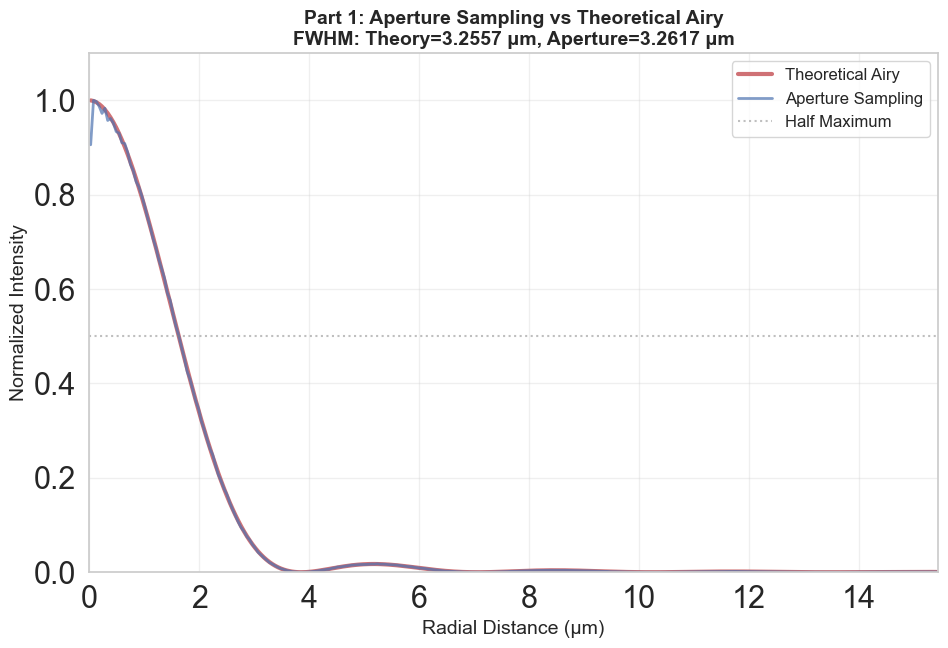


PART 1 METRICS: Aperture Sampling vs Theoretical Airy
RMSE                                     0.005714
FWHM (Theory)                            3.2557 μm
FWHM (Aperture)                          3.2617 μm
FWHM Error                               0.0059 μm


In [6]:
# Calculate radial distances
r_ap = np.sqrt(x_ap**2 + y_ap**2)

# Create radial histogram with higher resolution
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2

hist_r_ap, _ = np.histogram(r_ap, bins=r_bins)

# Normalize by bin area (annulus area = pi * (r_outer^2 - r_inner^2))
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)
intensity_r_ap = hist_r_ap / bin_areas

# Normalize to peak
intensity_r_ap = intensity_r_ap / np.max(intensity_r_ap)

# Theoretical Airy pattern
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

# Compute FWHM
fwhm_theory = compute_fwhm(r_centers, airy_theory)
fwhm_aperture = compute_fwhm(r_centers, intensity_r_ap)

# Plot - single panel matching convergence notebook style
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.plot(r_centers, airy_theory, 'r-', linewidth=3, label='Theoretical Airy', alpha=0.8)
ax.plot(r_centers, intensity_r_ap, 'b-', linewidth=2, label='Aperture Sampling', alpha=0.7)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='Half Maximum')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title(f'Part 1: Aperture Sampling vs Theoretical Airy\nFWHM: Theory={fwhm_theory:.4f} μm, Aperture={fwhm_aperture:.4f} μm', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/part1_radial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate RMSE
rmse_part1 = np.sqrt(np.mean((intensity_r_ap - airy_theory)**2))

# Print metrics for Part 1
print("\n" + "="*80)
print("PART 1 METRICS: Aperture Sampling vs Theoretical Airy")
print("="*80)
print(f"{'RMSE':<40} {rmse_part1:.6f}")
print(f"{'FWHM (Theory)':<40} {fwhm_theory:.4f} μm")
print(f"{'FWHM (Aperture)':<40} {fwhm_aperture:.4f} μm")
print(f"{'FWHM Error':<40} {abs(fwhm_aperture - fwhm_theory):.4f} μm")
print("="*80)

## Part 2: Aperture Sampling vs Angular Spectrum Method

### 2D Pattern Comparison

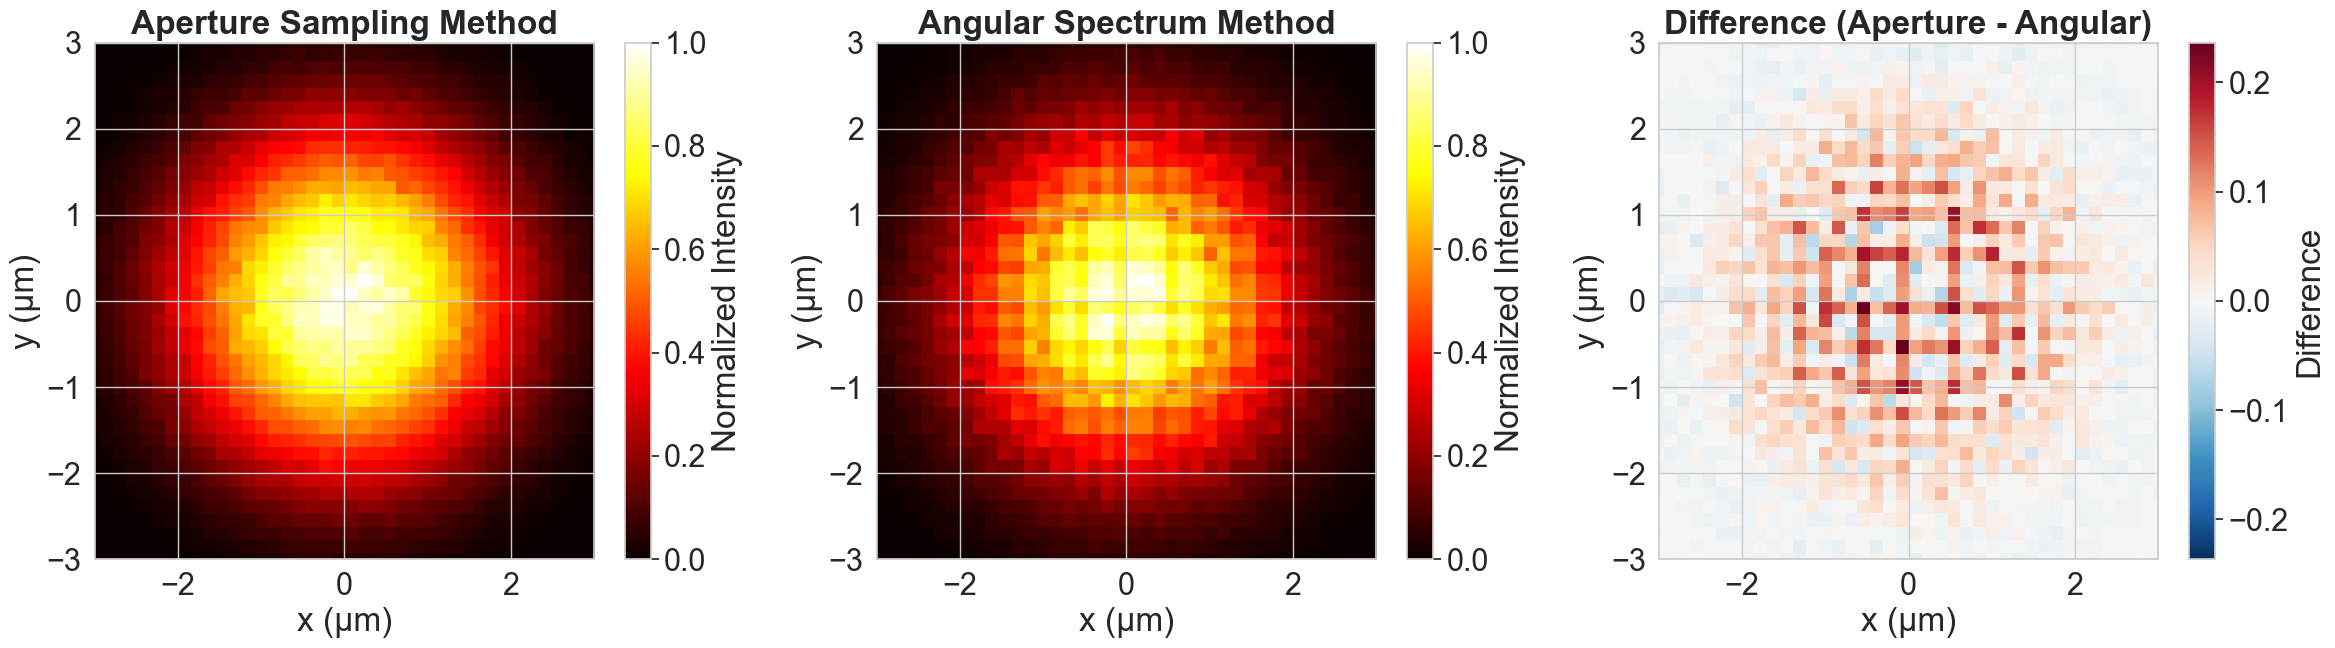

Max absolute difference: 0.236482


In [7]:
# Create 2D histogram for angular spectrum
hist_ang, _, _ = np.histogram2d(
    x_ang, y_ang, bins=bins_2d,
    range=[[-plot_range, plot_range], [-plot_range, plot_range]]
)

# Normalize
hist_ang_norm = hist_ang / np.max(hist_ang)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Aperture sampling
im1 = axes[0].imshow(hist_ap_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[0].set_title('Aperture Sampling Method', fontweight='bold')
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
plt.colorbar(im1, ax=axes[0], label='Normalized Intensity')

# Angular spectrum
im2 = axes[1].imshow(hist_ang_norm.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='hot', aspect='auto', vmin=0, vmax=1)
axes[1].set_title('Angular Spectrum Method', fontweight='bold')
axes[1].set_xlabel('x (μm)')
axes[1].set_ylabel('y (μm)')
plt.colorbar(im2, ax=axes[1], label='Normalized Intensity')

# Difference
diff_methods = hist_ap_norm - hist_ang_norm
max_diff_methods = np.abs(diff_methods).max()
im3 = axes[2].imshow(diff_methods.T, origin='lower', 
                     extent=[-plot_range, plot_range, -plot_range, plot_range],
                     cmap='RdBu_r', aspect='auto', vmin=-max_diff_methods, vmax=max_diff_methods)
axes[2].set_title('Difference (Aperture - Angular)', fontweight='bold')
axes[2].set_xlabel('x (μm)')
axes[2].set_ylabel('y (μm)')
plt.colorbar(im3, ax=axes[2], label='Difference')

# Set all xlim and ylim to be -3,3
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.savefig(f'{output_dir}/part2_2d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max absolute difference: {max_diff_methods:.6f}")

### Radial Profile: Aperture Sampling vs Angular Spectrum

/var/folders/t1/s8yj2ln96qv9sr5bwcjsq4mm0000gn/T/ipykernel_6967/194630617.py:20: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(r_centers, intensity_r_ap, 'b-', linewidth=3, label='Aperture Sampling', alpha=0.7, linestyle='-')
/var/folders/t1/s8yj2ln96qv9sr5bwcjsq4mm0000gn/T/ipykernel_6967/194630617.py:21: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "g-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(r_centers, intensity_r_ang, 'g-', linewidth=3, label='Angular Spectrum', alpha=0.7, linestyle='-')


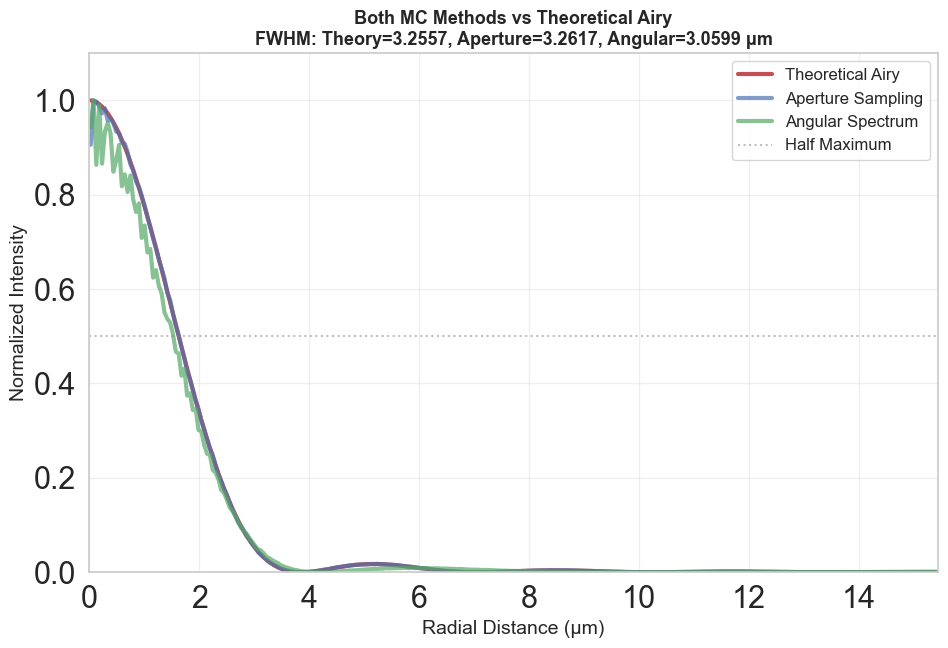

In [8]:
# Calculate radial distances for angular spectrum
r_ang = np.sqrt(x_ang**2 + y_ang**2)

# Create radial histogram for angular spectrum
hist_r_ang, _ = np.histogram(r_ang, bins=r_bins)

# Normalize by bin area
intensity_r_ang = hist_r_ang / bin_areas

# Normalize to peak
intensity_r_ang = intensity_r_ang / np.max(intensity_r_ang)

# Compute FWHM for angular spectrum
fwhm_angular = compute_fwhm(r_centers, intensity_r_ang)

# Plot - single panel matching convergence notebook style
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

ax.plot(r_centers, airy_theory, 'r-', linewidth=3, label='Theoretical Airy', alpha=1)
ax.plot(r_centers, intensity_r_ap, 'b-', linewidth=3, label='Aperture Sampling', alpha=0.7, linestyle='-')
ax.plot(r_centers, intensity_r_ang, 'g-', linewidth=3, label='Angular Spectrum', alpha=0.7, linestyle='-')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='Half Maximum')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title(f'Both MC Methods vs Theoretical Airy\nFWHM: Theory={fwhm_theory:.4f}, Aperture={fwhm_aperture:.4f}, Angular={fwhm_angular:.4f} μm', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(f'{output_dir}/part2_radial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Calculate metrics for aperture sampling vs theory using metrics module
nrmse_ap = metrics.nrmse(intensity_r_ap, airy_theory)
fid_ap = metrics.fidelity(airy_theory, intensity_r_ap)
corr_ap = metrics.correlationquality(airy_theory, intensity_r_ap)
rst_ap = metrics.rst(airy_theory, intensity_r_ap)
rmse_ap = metrics.rmse(intensity_r_ap, airy_theory)

# Calculate metrics for angular spectrum vs theory
nrmse_ang = metrics.nrmse(intensity_r_ang, airy_theory)
fid_ang = metrics.fidelity(airy_theory, intensity_r_ang)
corr_ang = metrics.correlationquality(airy_theory, intensity_r_ang)
rst_ang = metrics.rst(airy_theory, intensity_r_ang)
rmse_ang = metrics.rmse(intensity_r_ang, airy_theory)

# Verify Linfoot relationship: F = 2Q - S
linfoot_diff_ap = metrics.verify_linfoot_relationship(fid_ap, corr_ap, rst_ap)
linfoot_diff_ang = metrics.verify_linfoot_relationship(fid_ang, corr_ang, rst_ang)

# Print comparison table
print("\n" + "="*90)
print("PART 2 METRICS: Radial Profile vs Theoretical Airy")
print("="*90)
print(f"{'Metric':<30} {'Aperture Sampling':<30} {'Angular Spectrum':<30}")
print("-"*90)
print(f"{'RMSE':<30} {rmse_ap:<30.6f} {rmse_ang:<30.6f}")
print(f"{'NRMSE (lower better)':<30} {nrmse_ap:<30.6f} {nrmse_ang:<30.6f}")
print(f"{'Fidelity (1.0 = perfect)':<30} {fid_ap:<30.6f} {fid_ang:<30.6f}")
print(f"{'Correlation Quality':<30} {corr_ap:<30.6f} {corr_ang:<30.6f}")
print(f"{'Relative Structural (RST)':<30} {rst_ap:<30.6f} {rst_ang:<30.6f}")
print(f"{'FWHM (μm)':<30} {fwhm_aperture:<30.4f} {fwhm_angular:<30.4f}")
print(f"{'FWHM Error vs Theory (μm)':<30} {abs(fwhm_aperture - fwhm_theory):<30.4f} {abs(fwhm_angular - fwhm_theory):<30.4f}")
print("="*90)

# Verify Linfoot relationship
print("\nLinfoot Relationship Verification (F = 2Q - S):")
print(f"  Aperture Sampling:")
print(f"    F = {fid_ap:.6f}")
print(f"    2Q - S = {2*corr_ap - rst_ap:.6f}")
print(f"    |Difference| = {linfoot_diff_ap:.9f}")
print(f"  Angular Spectrum:")
print(f"    F = {fid_ang:.6f}")
print(f"    2Q - S = {2*corr_ang - rst_ang:.6f}")
print(f"    |Difference| = {linfoot_diff_ang:.9f}")

# Determine which is better
print("\nSummary:")
if rmse_ap < rmse_ang:
    print(f"  - Aperture Sampling has {((rmse_ang - rmse_ap) / rmse_ang * 100):.2f}% lower RMSE")
else:
    print(f"  - Angular Spectrum has {((rmse_ap - rmse_ang) / rmse_ap * 100):.2f}% lower RMSE")

if fid_ap > fid_ang:
    print(f"  - Aperture Sampling has higher fidelity ({fid_ap:.6f} vs {fid_ang:.6f})")
else:
    print(f"  - Angular Spectrum has higher fidelity ({fid_ang:.6f} vs {fid_ap:.6f})")

if abs(fwhm_aperture - fwhm_theory) < abs(fwhm_angular - fwhm_theory):
    print(f"  - Aperture Sampling has FWHM closer to theory (error: {abs(fwhm_aperture - fwhm_theory):.4f} vs {abs(fwhm_angular - fwhm_theory):.4f} μm)")
else:
    print(f"  - Angular Spectrum has FWHM closer to theory (error: {abs(fwhm_angular - fwhm_theory):.4f} vs {abs(fwhm_aperture - fwhm_theory):.4f} μm)")


PART 2 METRICS: Radial Profile vs Theoretical Airy
Metric                         Aperture Sampling              Angular Spectrum              
------------------------------------------------------------------------------------------
RMSE                           0.005714                       0.022802                      
NRMSE (lower better)           0.005714                       0.022802                      
Fidelity (1.0 = perfect)       0.999616                       0.998143                      
Correlation Quality            0.999808                       0.999071                      
Relative Structural (RST)      1.000000                       1.000000                      
FWHM (μm)                      3.2617                         3.0599                        
FWHM Error vs Theory (μm)      0.0059                         0.1959                        

Linfoot Relationship Verification (F = 2Q - S):
  Aperture Sampling:
    F = 0.999616
    2Q - S = 0.999616
    

## Statistical Comparison

In [10]:
print("\nDistribution Statistics:")
print("=" * 60)
print(f"\nAperture Sampling Method:")
print(f"  Mean r: {np.mean(r_ap):.6f} μm")
print(f"  Std r:  {np.std(r_ap):.6f} μm")
print(f"  Max r:  {np.max(r_ap):.6f} μm")

print(f"\nAngular Spectrum Method:")
print(f"  Mean r: {np.mean(r_ang):.6f} μm")
print(f"  Std r:  {np.std(r_ang):.6f} μm")
print(f"  Max r:  {np.max(r_ang):.6f} μm")

print(f"\nRelative difference in mean r: {np.abs(np.mean(r_ap) - np.mean(r_ang)) / np.mean(r_ap) * 100:.2f}%")
print(f"Relative difference in std r:  {np.abs(np.std(r_ap) - np.std(r_ang)) / np.std(r_ap) * 100:.2f}%")


Distribution Statistics:

Aperture Sampling Method:
  Mean r: 2.809274 μm
  Std r:  4.171123 μm
  Max r:  38.537807 μm

Angular Spectrum Method:
  Mean r: 2.441307 μm
  Std r:  3.621173 μm
  Max r:  577.263660 μm

Relative difference in mean r: 13.10%
Relative difference in std r:  13.18%
